In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
#problem statment “Given multiple features, predict a continuous target variable.”

In [33]:
df=pd.read_csv("/content/linear_regression_dataset (2).csv")
df


,Feature1,Feature2,Feature3,Category,Name,Target
0,54.967142,72.642384,62,A,Alice,371.099650
1,48.617357,64.446117,63,B,Charlie,299.184743
2,56.476885,61.820944,25,C,Bob,319.605931
3,65.230299,62.149045,56,C,Alice,348.440917
4,47.658466,41.569469,33,C,Bob,201.644393
...,...,...,...,...,...,...
200,54.967142,72.642384,62,A,Alice,371.099650
201,48.617357,64.446117,63,B,Charlie,299.184743
202,56.476885,61.820944,25,C,Bob,319.605931
203,65.230299,62.149045,56,C,Alice,348.440917


In [34]:
#EDA
df.isnull().sum()

,0
Feature1,10
Feature2,8
Feature3,0
Category,0
Name,0
Target,0


In [35]:
df.info()  #having 4 numerical 3 object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  195 non-null    float64
 1   Feature2  197 non-null    float64
 2   Feature3  205 non-null    int64  
 3   Category  205 non-null    object 
 4   Name      205 non-null    object 
 5   Target    205 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 9.7+ KB


In [36]:
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=df[col].fillna(df[col].mode()[0])
  else:
    df[col]=df[col].fillna(df[col].mean())
df.isnull().sum()

,0
Feature1,0
Feature2,0
Feature3,0
Category,0
Name,0
Target,0


In [37]:
df.duplicated().sum()

np.int64(5)

In [38]:
df=df.drop_duplicates()

In [39]:
df.duplicated().sum()

np.int64(0)

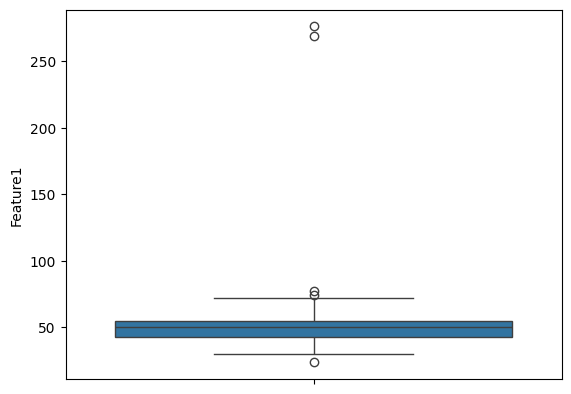

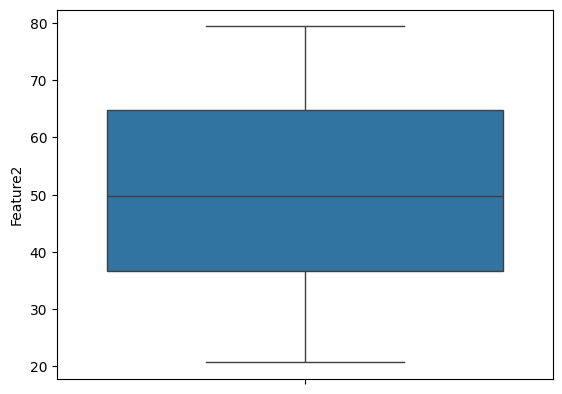

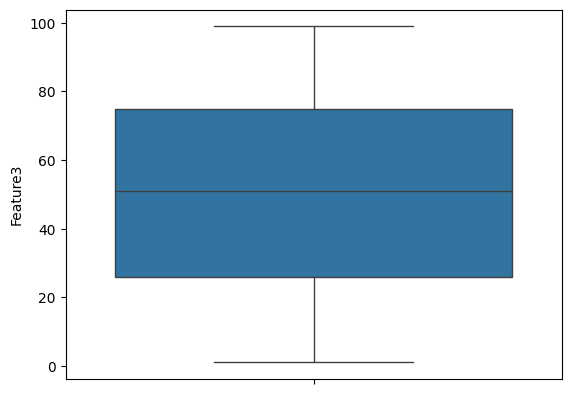

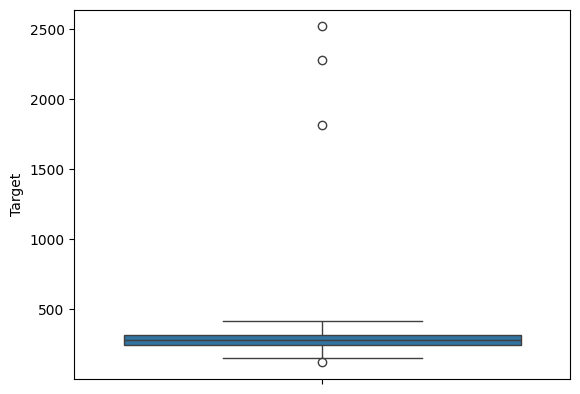

In [40]:
for col in df.columns:
  if df[col].dtype !="object":
    sns.boxplot(df[col])
    plt.show()

In [41]:
#dont consider  the outlliers of trageted coloumn
q1=df["Feature1"].quantile(0.25)
q3=df['Feature1'].quantile(0.75)
IQR=q3-q1
LB=q1-IQR*1.5
UB=q3+IQR*1.5
df=df[(df["Feature1"]>LB) &(df['Feature1']<UB)].copy()

In [42]:
#LabelEncoding
from sklearn.preprocessing import LabelEncoder
Le=LabelEncoder()
for col in df.columns:
  if df[col].dtype=="object":
    df[col]=Le.fit_transform(df[col])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  195 non-null    float64
 1   Feature2  195 non-null    float64
 2   Feature3  195 non-null    int64  
 3   Category  195 non-null    int64  
 4   Name      195 non-null    int64  
 5   Target    195 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 10.7 KB


In [43]:
#Finally no null,no duplicates,no outyliers,no object

In [44]:
x=df.drop("Target",axis=1)
x

,Feature1,Feature2,Feature3,Category,Name
0,54.967142,72.642384,62,0,0
1,48.617357,64.446117,63,1,2
2,56.476885,61.820944,25,2,1
3,65.230299,62.149045,56,2,0
4,47.658466,41.569469,33,2,1
...,...,...,...,...,...
195,53.853174,27.129075,16,2,0
196,41.161426,27.051575,8,2,3
197,51.537251,58.952618,4,0,3
198,50.582087,64.762693,4,1,3


In [45]:
y=df["Target"]

In [46]:
#split the data
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression
Le=LinearRegression()
Le.fit(x_train,y_train)

LinearRegression()

In [48]:
y_test

,Target
141,337.167927
16,290.158562
159,2517.322809
98,290.022854
69,304.076123
157,311.873744
56,243.893851
15,284.066185
115,317.193090
114,254.674838


In [49]:
#testing
model_ans=Le.predict(x_test)
model_ans

array([367.68420085, 317.92420917, 294.03541089, 283.58925622,
       236.56914296, 348.82579174, 246.0765841 , 297.08716091,
       279.99669439, 282.99858365, 306.2167393 , 223.53526613,
       270.29853256, 341.44886642, 304.52412076, 344.18984876,
       226.57144774, 238.21462457, 280.02011006, 296.68261572,
       337.7121897 , 277.41361701, 336.39802481, 239.05095696,
       307.16012858, 324.29812784, 204.24604218, 274.35260968,
       302.98052799, 354.33465292, 265.04165568, 254.55272545,
       230.47446529, 234.62029202, 194.82755068, 328.38896774,
       212.61137093, 199.85705301, 260.18037551])

In [50]:
from sklearn.metrics import r2_score#method used to check accurecy
r2_score(model_ans,y_test)*100

-14003.393430662887

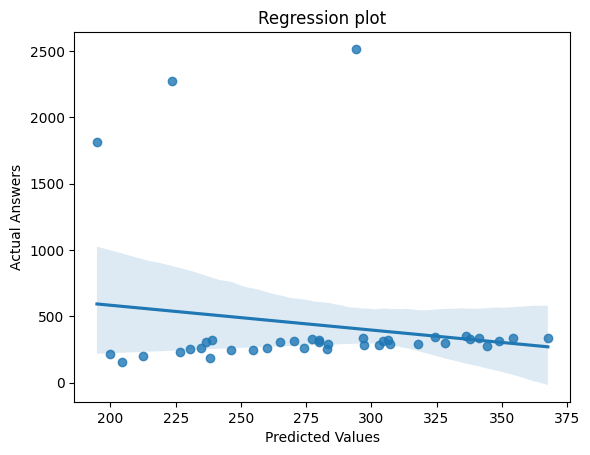

In [51]:
sns.regplot(x=model_ans,y=y_test)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Answers')
plt.title("Regression plot")
plt.show()